In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

from datasets import load_dataset
from transformers import BertTokenizer, BertForSequenceClassification
from torch.optim import AdamW
from tqdm import tqdm
import numpy as np

/Users/jesanahammed/Math498-Project/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    elif torch.backends.mps.is_available():
        return torch.device("mps")
    else:
        return torch.device("cpu")

device = get_device()
print("Using device:", device)

Using device: mps


In [3]:
def loaddataset():
    dataset = load_dataset("imdb")
    tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
    def tokenize(example):
        return tokenizer(
            example["text"],
            padding="max_length",
            truncation=True,
            max_length=128
        )

    dataset = dataset.map(tokenize, batched=True)
    dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

    train_loader = DataLoader(dataset["train"], batch_size=16, shuffle=True)
    test_loader = DataLoader(dataset["test"], batch_size=16)
    return train_loader, test_loader


train_loader, text_loader = loaddataset()
print(len(train_loader))


Map: 100%|██████████| 50000/50000 [00:05<00:00, 9318.88 examples/s]

1563


In [4]:
model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)
model.to(device)

optimizer = AdamW(model.parameters(), lr=2e-5)

def train_bert(model, loader, epochs=1):
    model.train()
    for epoch in range(epochs):
        loop = tqdm(loader)
        for batch in loop:
            optimizer.zero_grad()

            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss
            loss.backward()
            optimizer.step()

            loop.set_description(f"Epoch {epoch}")
            loop.set_postfix(loss=loss.item())

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6976.37it/s]
BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider tr

In [5]:
train_bert(model, train_loader, epochs=1) 

Epoch 0: 100%|██████████| 1563/1563 [05:12<00:00,  5.00it/s, loss=0.308] 


In [6]:
def extract_hidden_states(model, loader, max_samples=5000):
    model.eval()

    all_h = []
    all_labels = []

    count = 0

    with torch.no_grad():
        for batch in tqdm(loader):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            outputs = model.bert(
                input_ids=input_ids,
                attention_mask=attention_mask,
                output_hidden_states=True
            )

            last_hidden = outputs.hidden_states[-1]  # (batch, seq_len, 768)
            cls_vectors = last_hidden[:, 0, :]       # CLS token

            all_h.append(cls_vectors.cpu())
            all_labels.append(labels.cpu())

            count += cls_vectors.size(0)
            if count >= max_samples:
                break

    H = torch.cat(all_h)
    Y = torch.cat(all_labels)

    return H, Y

H, Y = extract_hidden_states(model, train_loader)
print("Hidden shape:", H.shape)

 20%|█▉        | 312/1563 [00:16<01:06, 18.85it/s]

Hidden shape: torch.Size([5008, 768])


In [7]:
H_mean = H.mean(dim=0)
H_std = H.std(dim=0) + 1e-6

H_norm = (H - H_mean) / H_std

In [8]:
class SparseAutoencoder(nn.Module):
    def __init__(self, input_dim=768, hidden_dim=5000):
        super().__init__()
        self.encoder = nn.Linear(input_dim, hidden_dim)
        self.decoder = nn.Linear(hidden_dim, input_dim)

    def forward(self, x):
        z = F.relu(self.encoder(x))     # sparse activations
        x_hat = self.decoder(z)
        return x_hat, z

In [9]:
sae = SparseAutoencoder(input_dim=768, hidden_dim=5000).to(device)

optimizer_sae = torch.optim.Adam(sae.parameters(), lr=1e-3)

lambda_l1 = 1e-3
epochs = 10
batch_size = 128

dataset_sae = torch.utils.data.TensorDataset(H_norm)
loader_sae = DataLoader(dataset_sae, batch_size=batch_size, shuffle=True)

for epoch in range(epochs):
    total_loss = 0

    for (x,) in loader_sae:
        x = x.to(device)

        optimizer_sae.zero_grad()

        x_hat, z = sae(x)

        recon_loss = F.mse_loss(x_hat, x)
        l1_loss = z.abs().mean()

        loss = recon_loss + lambda_l1 * l1_loss
        loss.backward()
        optimizer_sae.step()

        total_loss += loss.item()

    print(f"Epoch {epoch}, Loss: {total_loss:.4f}")

Epoch 0, Loss: 10.9939
Epoch 1, Loss: 3.2627
Epoch 2, Loss: 2.0274
Epoch 3, Loss: 1.4685
Epoch 4, Loss: 1.1377
Epoch 5, Loss: 0.9242
Epoch 6, Loss: 0.7706
Epoch 7, Loss: 0.6613
Epoch 8, Loss: 0.5768
Epoch 9, Loss: 0.5174


In [10]:
sae.eval()

with torch.no_grad():
    _, Z = sae(H_norm.to(device))
    Z = Z.cpu()

In [11]:
pos_mask = (Y == 1)
neg_mask = (Y == 0)

pos_mean = Z[pos_mask].mean(dim=0)
neg_mean = Z[neg_mask].mean(dim=0)

diff = pos_mean - neg_mean

topk = torch.topk(diff.abs(), k=10)

print("Top features:", topk.indices)

Top features: tensor([2950, 4404, 1508, 4527, 3336, 3328,  687, 3911, 2093, 2659])


In [13]:
print(Z)

tensor([[0.6808, 0.3541, 0.0000,  ..., 0.0000, 0.0000, 0.2443],
        [0.1291, 0.2808, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [1.0086, 0.0000, 0.0851,  ..., 0.0000, 0.2397, 0.0000],
        ...,
        [0.0000, 0.2580, 0.0000,  ..., 0.0000, 0.0000, 0.6408],
        [0.5767, 0.2609, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.5802, 0.2539,  ..., 0.2460, 0.5958, 0.2298]])


In [17]:
zero_ratio = (Z == 0).float().mean()

print("Overall sparsity (fraction of zeros):", zero_ratio.item())

Overall sparsity (fraction of zeros): 0.4544173777103424


In [20]:
threshold = 1e-1

sparsity = (Z.abs() < threshold).float().mean()

print("Near-zero sparsity:", sparsity.item())

Near-zero sparsity: 0.5308067798614502


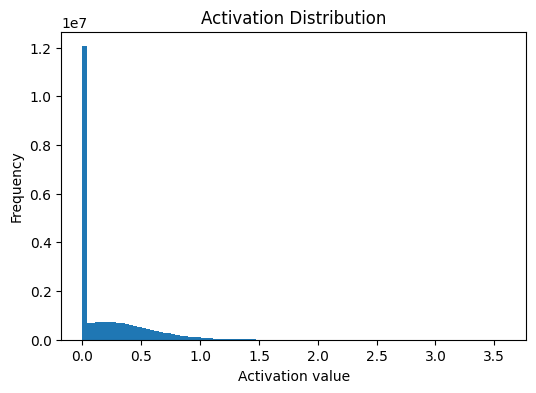

In [21]:
import matplotlib.pyplot as plt

vals = Z.detach().cpu().numpy().flatten()

plt.figure(figsize=(6,4))
plt.hist(vals, bins=100)
plt.title("Activation Distribution")
plt.xlabel("Activation value")
plt.ylabel("Frequency")
plt.show()

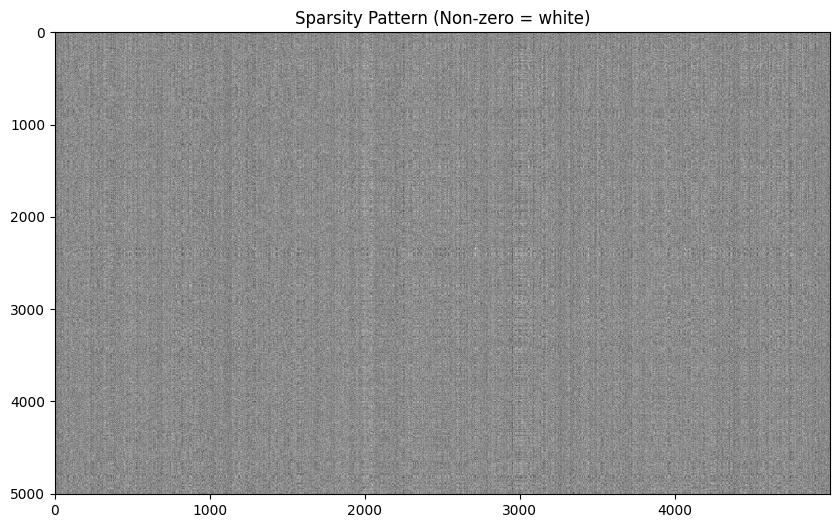

In [16]:
import matplotlib.pyplot as plt

binary = (Z != 0).float()

plt.figure(figsize=(10, 6))
plt.imshow(binary.cpu().numpy(), aspect='auto', cmap='gray')
plt.title("Sparsity Pattern (Non-zero = white)")
plt.show()

In [12]:
def get_top_examples(feature_idx, Z, dataset, k=5):
    values = Z[:, feature_idx]
    top_indices = torch.topk(values, k=k).indices

    for idx in top_indices:
        print("\n---")
        print(dataset["train"][int(idx)]["text"][:200])

# Example
get_top_examples(topk.indices[0].item(), Z, dataset)

NameError: name 'dataset' is not defined